Import some libraries..

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Mount drive with colab notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load Data into pandas dataframe
df = pd.read_csv("/content/drive/MyDrive/Datasets/Auto_MPG_Car_dataset.csv")
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [4]:
# Copy usefull data into new variable named df_final
df_final = df[["model","year","price","transmission","mileage","fuelType","tax","mpg","engineSize"]].copy()
df_final

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


Data cleaning Process...

In [5]:
# Drop null and duplicates value
df_final.dropna(inplace=True)
df_final.drop_duplicates(inplace=True)

In [6]:
# sum of null values in each column
df_final.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [7]:
# sum of duplicates values in each column
df_final.duplicated().sum()

np.int64(0)

In [8]:
# Discribe data
df_final.describe()

,year,price,mileage,tax,mpg,engineSize
count,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000,17812.000000
mean,2016.862396,12269.556310,23381.146362,113.315012,57.908696,1.350623
std,2.052039,4736.285417,19419.011045,62.034603,10.132696,0.432581
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10000.000000,30.000000,52.300000,1.000000
50%,2017.000000,11288.000000,18277.000000,145.000000,58.900000,1.200000
75%,2018.000000,15295.000000,31098.500000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [9]:
# Check size of data
df_final.shape

(17812, 9)

In [10]:
df_final.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64


Exploratory Data Analysis (EDA)

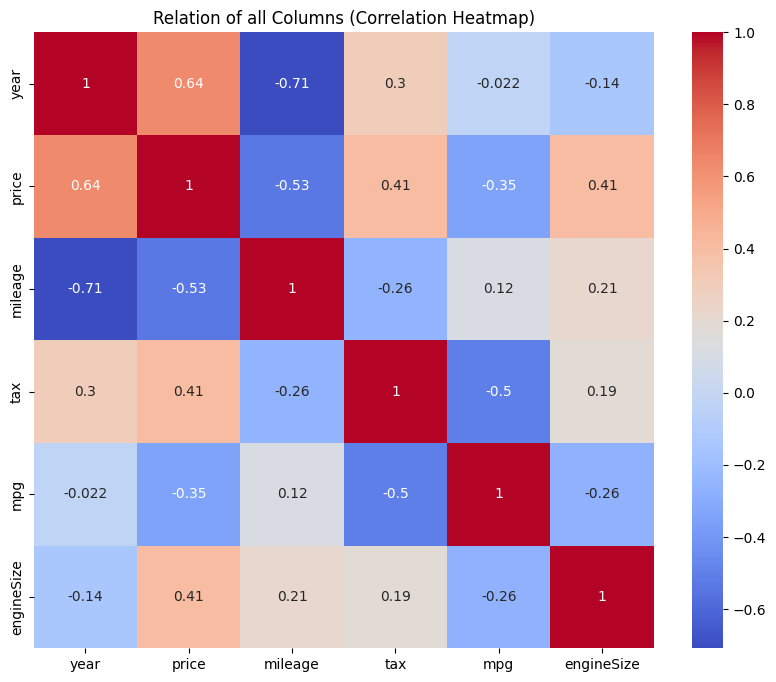

In [48]:
# check relation of all numeric cloumns
plt.figure(figsize=(10, 8))

sns.heatmap(df_final.corr(numeric_only = True), annot=True, cmap="coolwarm")
plt.title("Relation of all Columns (Correlation Heatmap)")
plt.show()

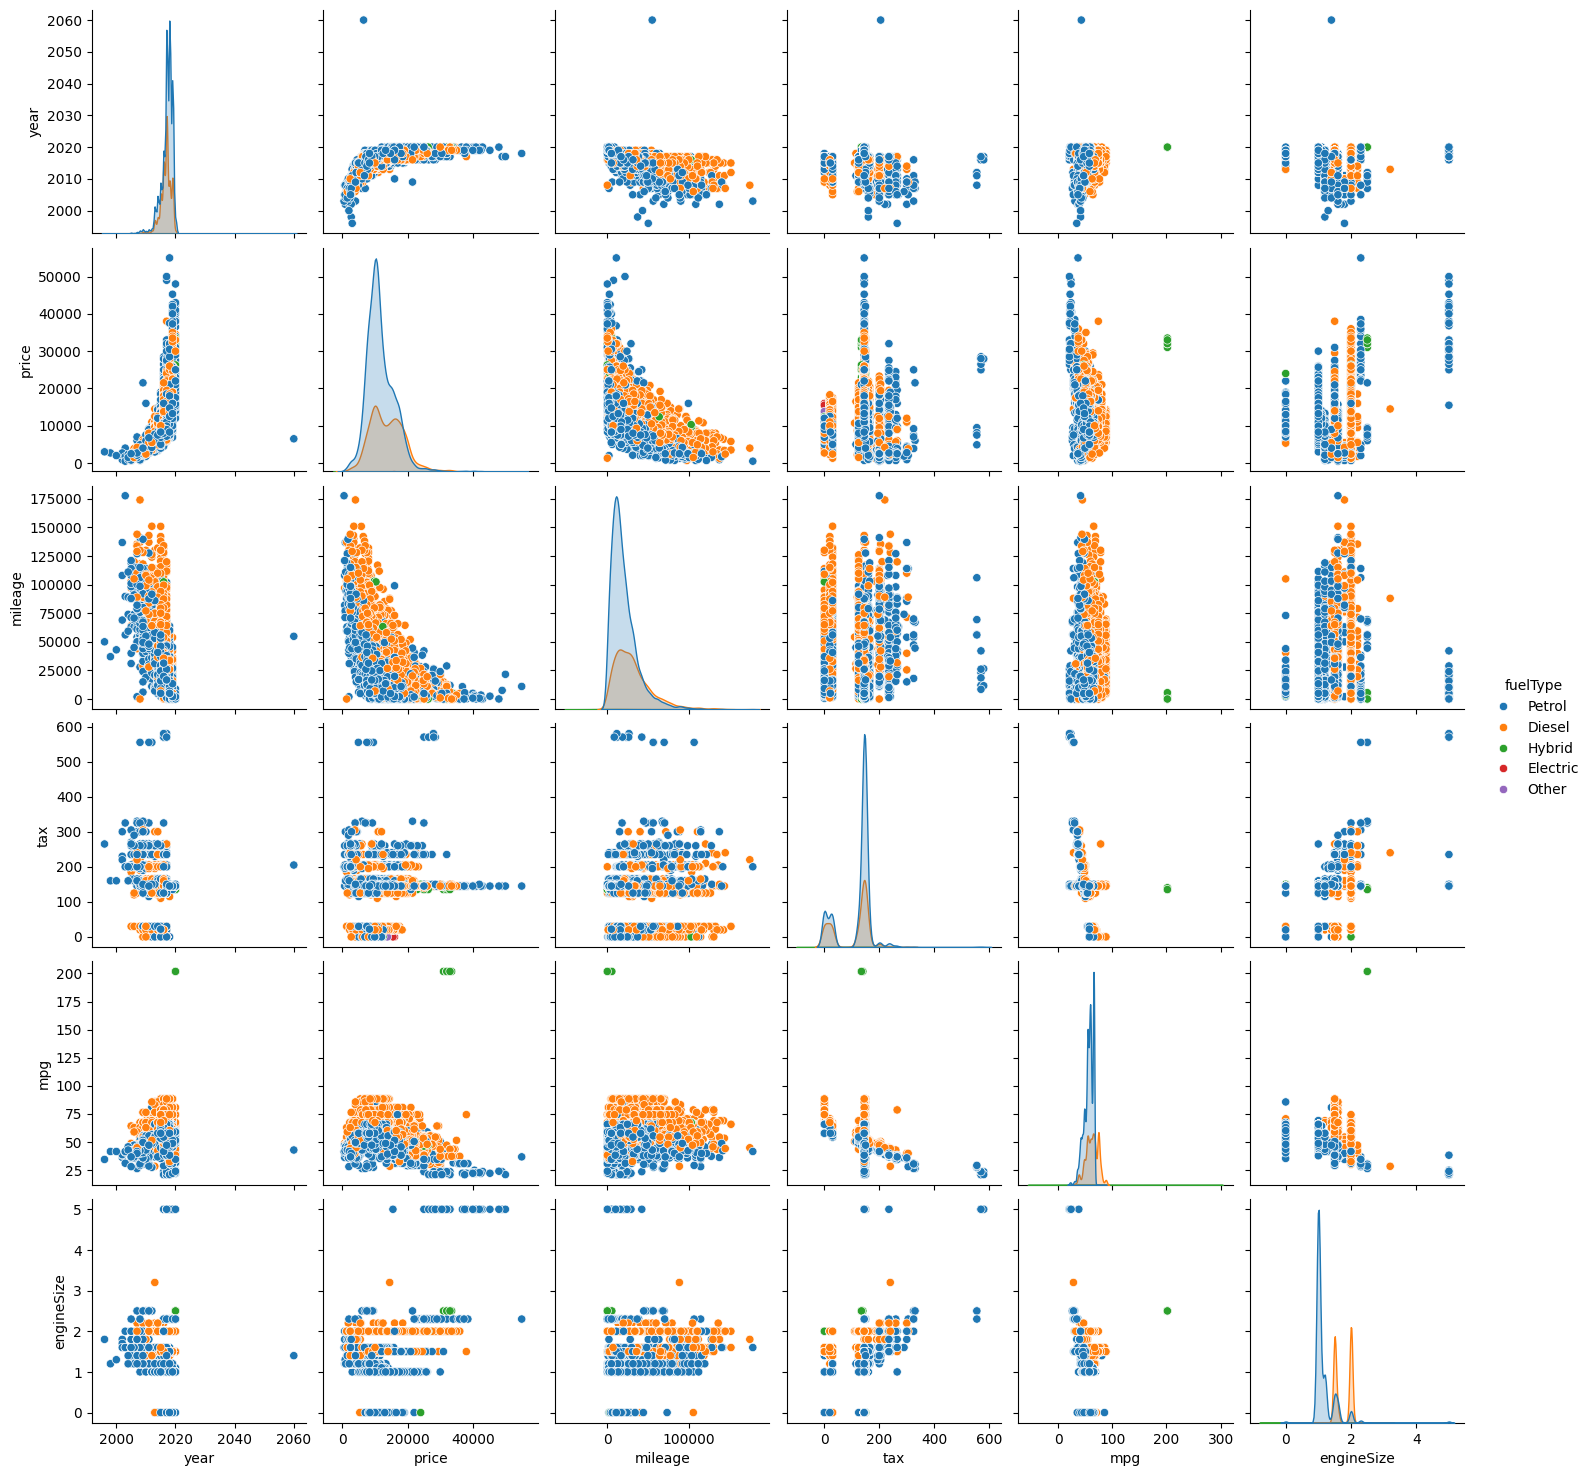

In [51]:
sns.pairplot(df_final, hue='fuelType')
plt.show()

Find and Remove outliers from the Price column.

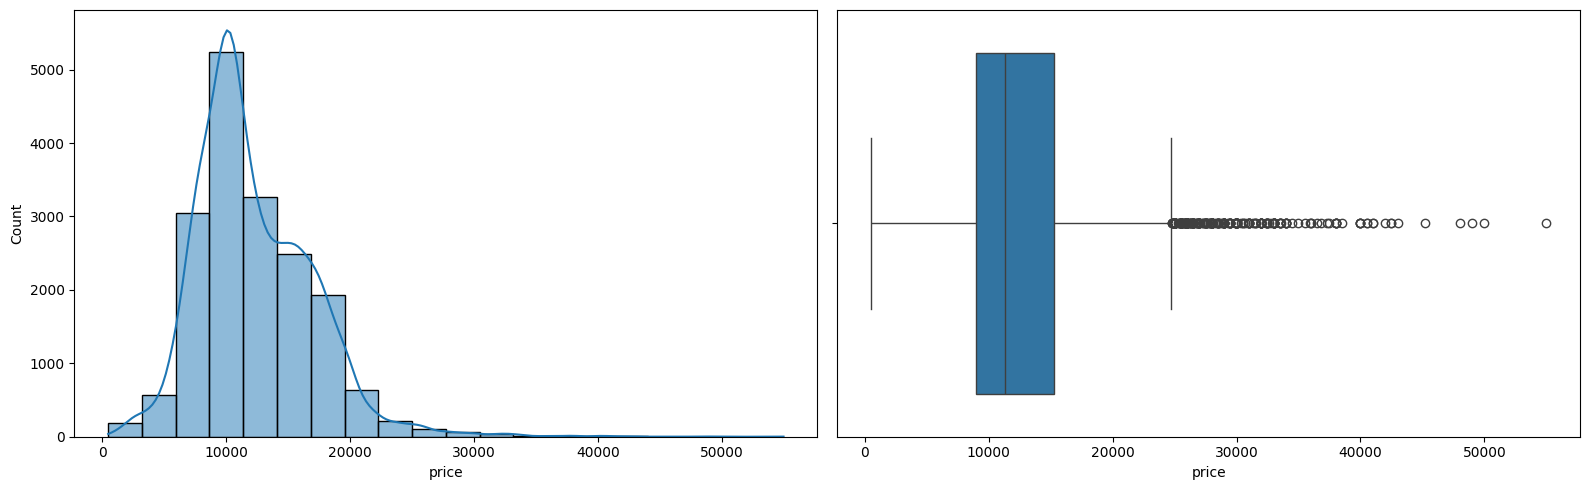

In [11]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["price"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["price"])

plt.tight_layout()
plt.show()

In [12]:
# Remove outilers using IQR method
p_Q1 = df_final["price"].quantile(0.25)
p_Q3 = df["price"].quantile(0.75)
p_IQR = p_Q3 - p_Q1

p_upper_limit = p_Q3 + 1.4 * p_IQR
p_lower_limit = p_Q1 - 1.5 * p_IQR

print(p_upper_limit)
print(p_lower_limit)

24119.0
-451.0


In [13]:
df_final[df_final["price"] >= p_upper_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
8,Kuga,2019,25500,Automatic,6894,Diesel,145,42.2,2.0
91,Focus,2016,24995,Manual,7997,Petrol,235,36.7,2.3
230,S-MAX,2020,34498,Semi-Auto,4623,Diesel,145,43.5,2.0
302,Mustang,2020,42489,Automatic,3500,Petrol,145,22.1,5.0
339,Mustang,2020,38489,Automatic,3500,Petrol,145,30.7,2.3
...,...,...,...,...,...,...,...,...,...
17838,S-MAX,2020,30000,Automatic,1000,Diesel,145,43.5,2.0
17866,Mustang,2020,48000,Manual,50,Petrol,145,23.9,5.0
17868,Kuga,2020,25050,Manual,50,Diesel,145,38.2,2.0
17890,Edge,2018,25999,Automatic,19458,Diesel,145,47.9,2.0


In [14]:
df_final[df_final["price"] <= p_lower_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize


In [15]:
# Data Triming
df_clean = df_final[(df_final["price"] <= p_upper_limit) & (df_final["price"] >= p_lower_limit)]

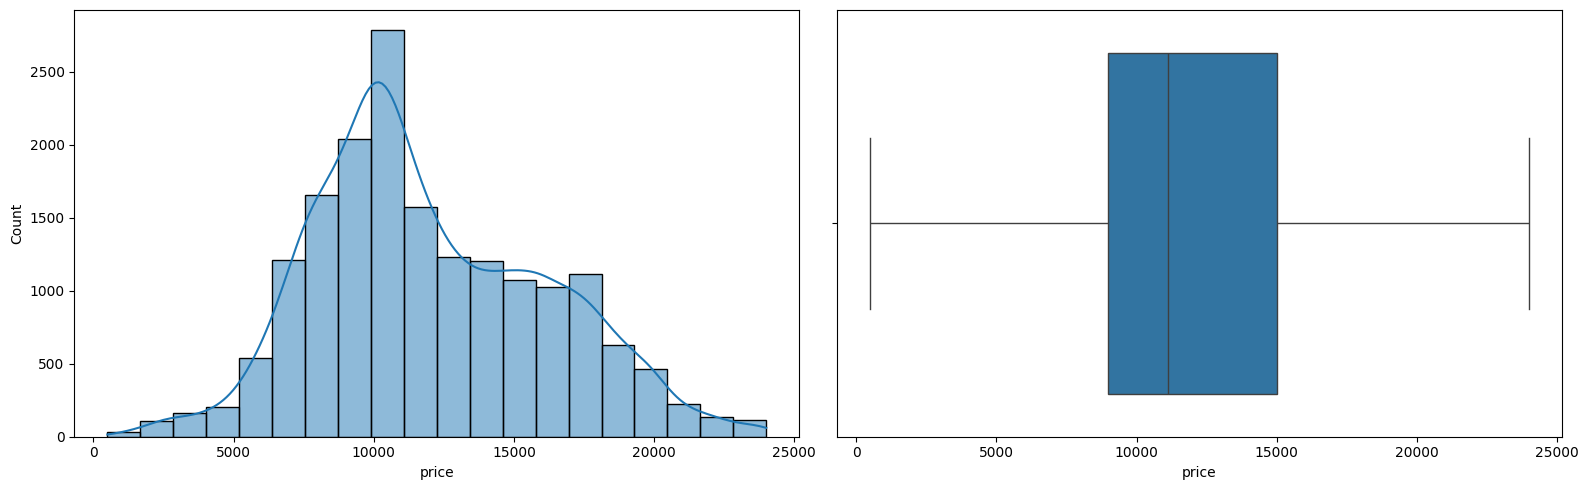

In [16]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_clean["price"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_clean["price"])

plt.tight_layout()
plt.show()

Find and Remove outliers from the Mileage column.

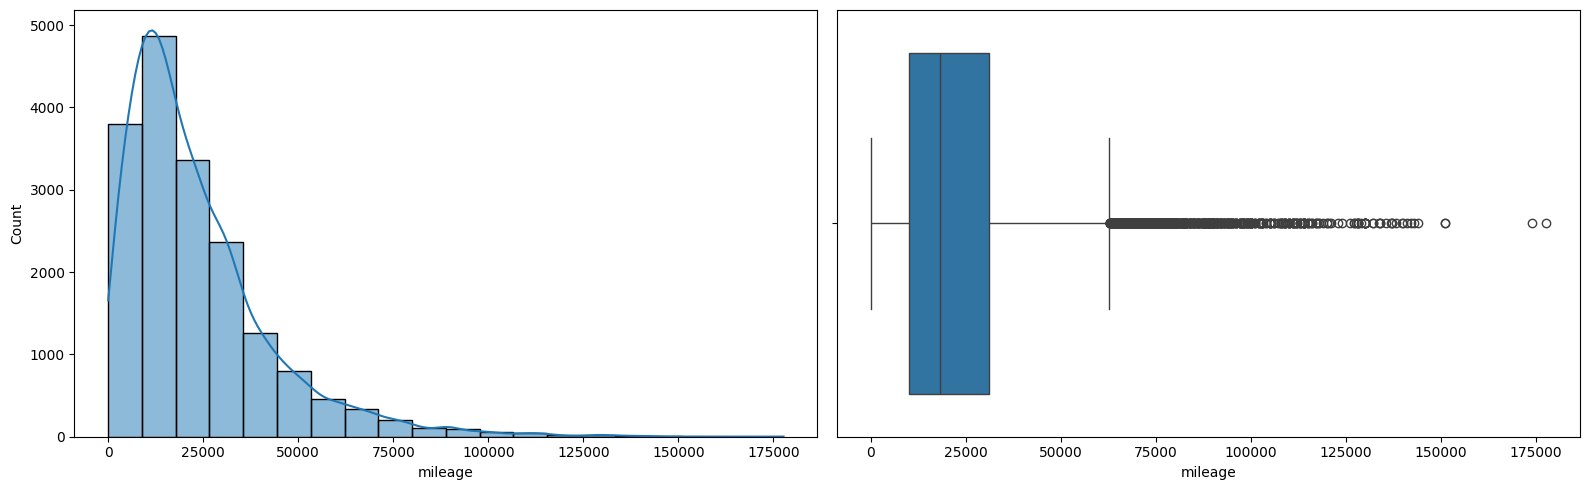

In [17]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["mileage"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["mileage"])

plt.tight_layout()
plt.show()

In [18]:
# Find and remove outilers using IQR method
m_Q1 = df_final["mileage"].quantile(0.25)
m_Q3 = df_final["mileage"].quantile(0.75)
m_IQR = m_Q3 - m_Q1

m_upper_limit = m_Q3 + 1.2 * m_IQR
m_lower_limit = m_Q1 - 1.5 * m_IQR

print(m_upper_limit)
print(m_lower_limit)

56416.7
-21647.75


In [19]:
df_final[df_final["mileage"] >= m_upper_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
23,Kuga,2014,8995,Manual,59000,Diesel,160,47.9,2.0
30,Fiesta,2016,7999,Manual,60730,Diesel,0,78.5,1.5
74,Fiesta,2014,6270,Manual,60888,Petrol,0,65.7,1.0
76,Fiesta,2013,4790,Manual,74128,Petrol,0,65.7,1.0
136,Focus,2015,7995,Manual,56655,Diesel,20,67.3,1.6
...,...,...,...,...,...,...,...,...,...
17784,Fiesta,2013,6000,Manual,58246,Petrol,30,54.3,1.2
17785,Fiesta,2012,5500,Manual,64068,Diesel,125,51.4,1.4
17835,Focus,2015,7500,Manual,67107,Diesel,0,74.3,1.5
17906,Kuga,2017,15499,Semi-Auto,64315,Diesel,145,54.3,2.0


In [20]:
df_final[df_final["mileage"] <= m_lower_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize


In [21]:
# Triming
df_clean = df_final[(df["mileage"] <= m_upper_limit) & (df_final["mileage"] >= m_lower_limit)]

/tmp/ipykernel_28170/4104937494.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_final[(df["mileage"] <= m_upper_limit) & (df_final["mileage"] >= m_lower_limit)]


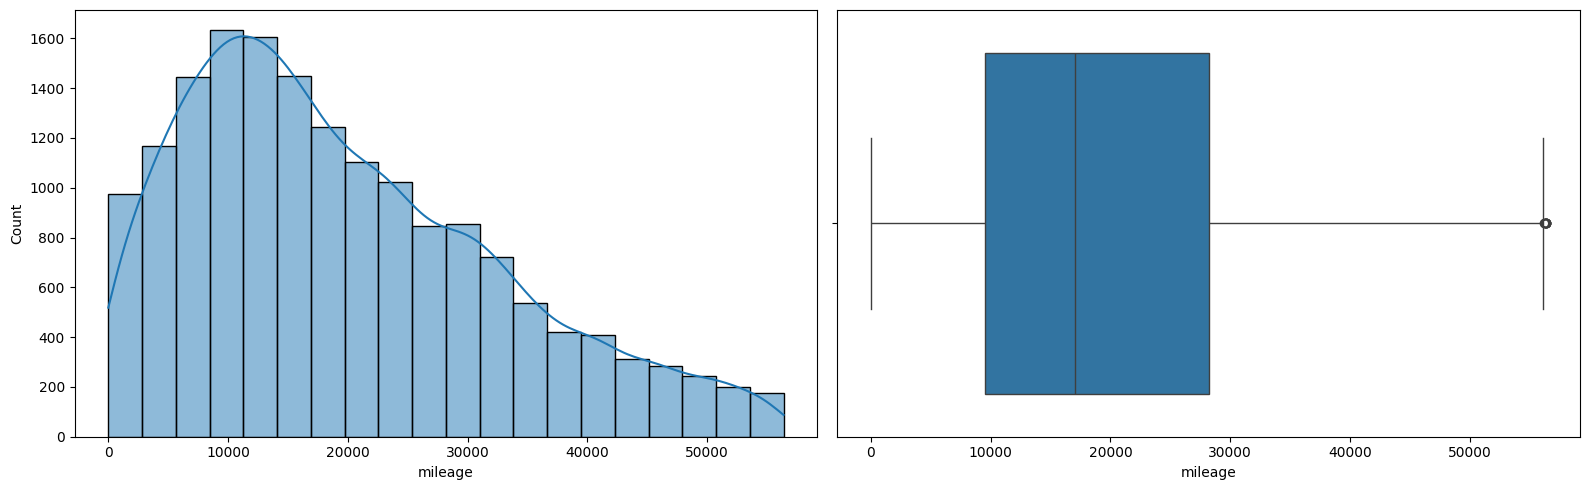

In [22]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_clean["mileage"], bins = 20, kde =True)

plt.subplot(1,2,2)
sns.boxplot(x = df_clean["mileage"])

plt.tight_layout()
plt.show()

Find and Remove outliers from the Tax column.

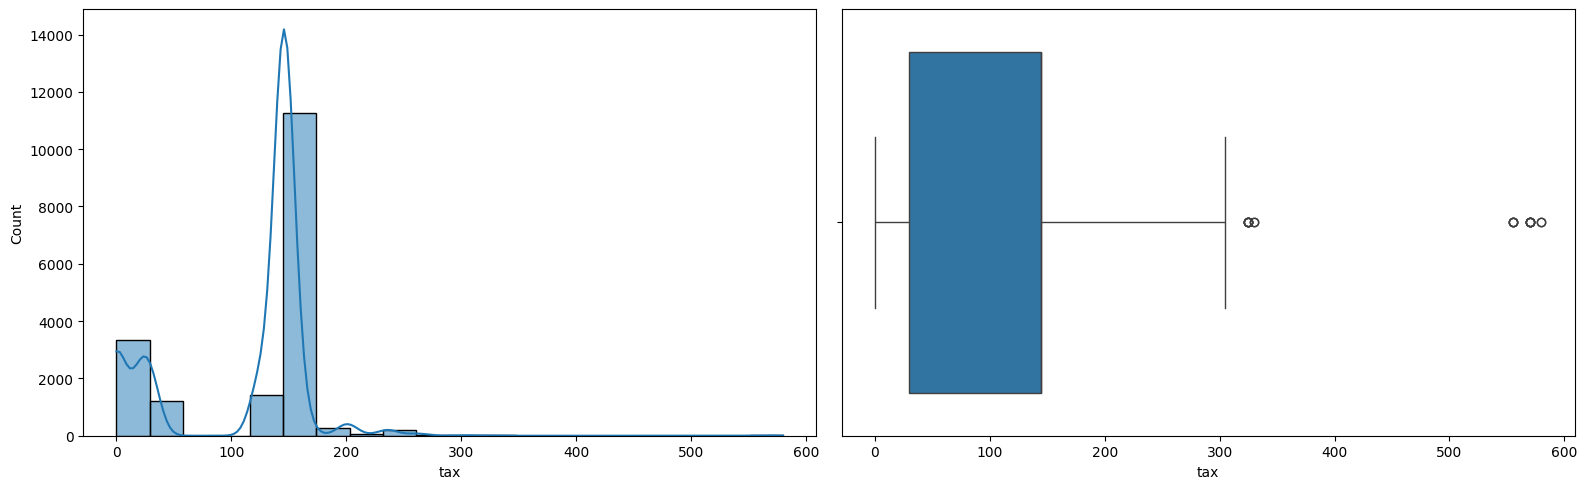

In [23]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["tax"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["tax"])

plt.tight_layout()
plt.show()

In [24]:
# Find and remove outliers using IQR method
t_Q1 = df_final["tax"].quantile(0.25)
t_Q3 = df_final["tax"].quantile(0.75)
t_IQR = t_Q3 - t_Q1

t_upper_limit = t_Q3 + 1.5 * t_IQR
t_lower_limit = t_Q1 - 1.5 * t_IQR

print(t_upper_limit)
print(t_lower_limit)

317.5
-142.5


In [25]:
df_final[df_final["tax"] >= t_upper_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
364,Mustang,2016,24999,Semi-Auto,42086,Petrol,570,23.5,5.0
3163,Mustang,2017,27890,Semi-Auto,26452,Petrol,580,23.5,5.0
3395,Mustang,2017,28000,Semi-Auto,23179,Petrol,570,23.5,5.0
3687,Mustang,2016,26475,Manual,12000,Petrol,570,20.9,5.0
6136,Mustang,2016,27999,Semi-Auto,26104,Petrol,570,20.8,5.0
9790,Mustang,2016,28490,Automatic,18500,Petrol,570,23.5,5.0
11097,Mustang,2016,27925,Manual,11600,Petrol,580,20.9,5.0
12400,Mustang,2017,28000,Semi-Auto,8470,Petrol,570,23.5,5.0
13741,Kuga,2012,9490,Automatic,56384,Petrol,555,27.4,2.5
13826,Mustang,2016,24990,Automatic,18000,Petrol,325,28.8,2.3


In [26]:
df_final[df_final["tax"] <= t_lower_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize


In [27]:
# Triming
df_clean = df_final[(df_final["tax"] <= t_upper_limit) & (df_final["tax"] >= t_lower_limit)]

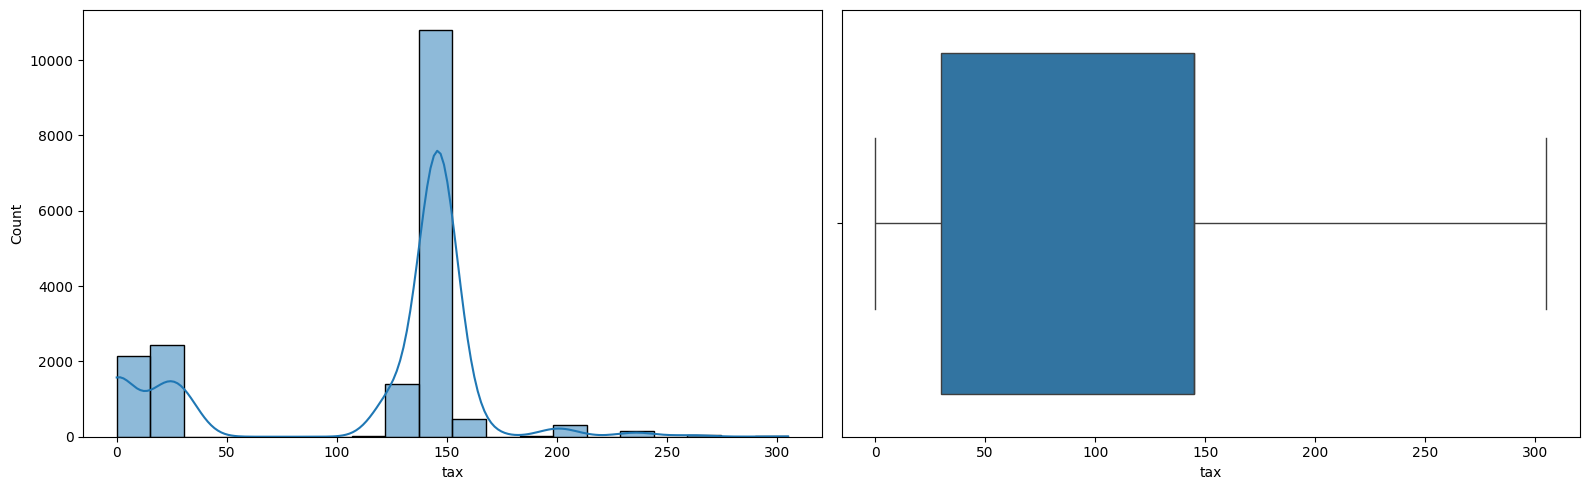

In [28]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_clean["tax"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_clean["tax"])

plt.tight_layout()
plt.show()

Find and Remove outliers from the MPG column.

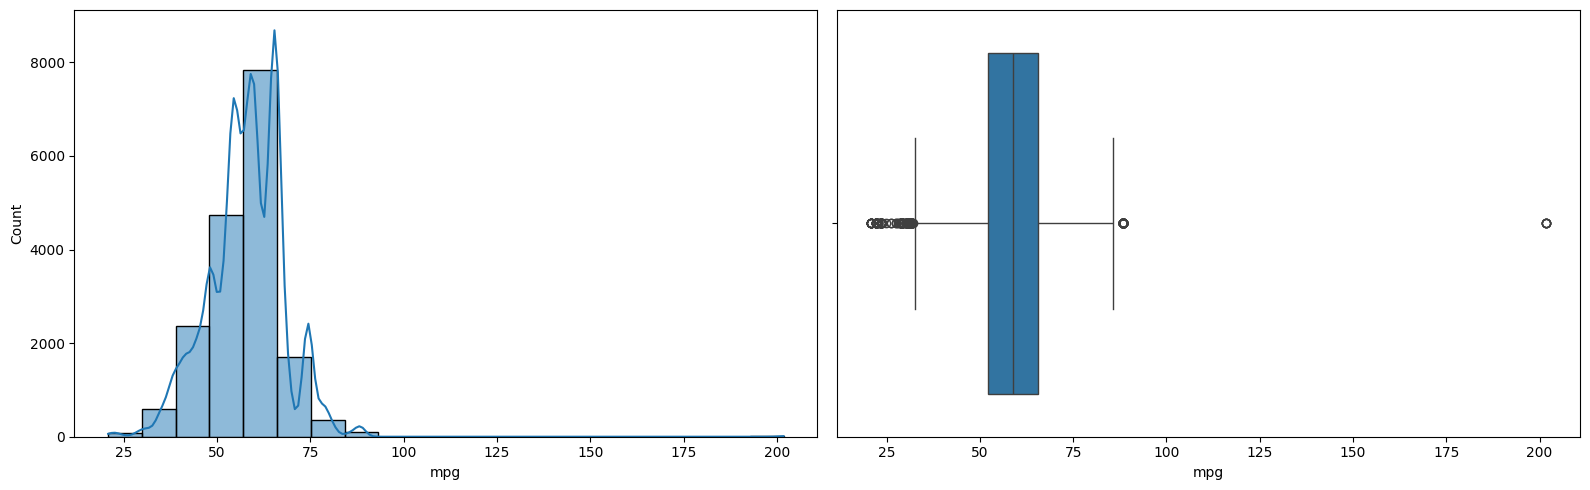

In [29]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_final["mpg"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_final["mpg"])

plt.tight_layout()
plt.show()

In [30]:
# Find and remove outliers using IQR method
mpg_Q1 = df_final["mpg"].quantile(0.25)
mpg_Q3 = df_final["mpg"].quantile(0.75)
mpg_IQR = mpg_Q3 - mpg_Q1

mpg_upper_limit = mpg_Q3 + 1.5 * mpg_IQR
mpg_lower_limit = mpg_Q1 - 1.5 * mpg_IQR

print(mpg_upper_limit)
print(mpg_lower_limit)

85.80000000000001
32.19999999999999


In [31]:
df_final[df_final["mpg"] >= mpg_upper_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
744,Fiesta,2016,7498,Manual,41271,Diesel,0,88.3,1.5
993,Fiesta,2016,7000,Manual,65000,Diesel,0,88.3,1.5
1031,Fiesta,2018,13495,Manual,14000,Diesel,145,88.3,1.5
1122,Fiesta,2016,8498,Manual,39271,Diesel,0,88.3,1.5
1683,Fiesta,2018,8991,Manual,30500,Diesel,145,88.3,1.5
...,...,...,...,...,...,...,...,...,...
16872,Fiesta,2016,7695,Manual,43680,Diesel,0,88.3,1.5
16961,Fiesta,2018,10600,Manual,14861,Diesel,145,88.3,1.5
17043,Fiesta,2017,6795,Manual,65290,Diesel,0,88.3,1.5
17510,Fiesta,2018,9100,Manual,55717,Diesel,145,88.3,1.5


In [32]:
df_final[df_final["mpg"] <= mpg_lower_limit]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
55,Tourneo Custom,2018,19995,Automatic,24568,Diesel,145,31.7,2.0
200,Kuga,2019,21498,Automatic,5354,Petrol,150,31.0,1.5
302,Mustang,2020,42489,Automatic,3500,Petrol,145,22.1,5.0
339,Mustang,2020,38489,Automatic,3500,Petrol,145,30.7,2.3
353,Mustang,2018,29998,Automatic,3000,Petrol,145,28.8,2.3
...,...,...,...,...,...,...,...,...,...
17316,Kuga,2011,7499,Manual,56000,Petrol,555,28.5,2.5
17430,S-MAX,2008,4890,Automatic,106000,Petrol,555,29.1,2.3
17441,Mondeo,2008,3890,Automatic,70000,Petrol,325,30.4,2.3
17866,Mustang,2020,48000,Manual,50,Petrol,145,23.9,5.0


In [33]:
# Triming
df_clean = df_final[(df_final["mpg"] <= mpg_upper_limit) & (df_final["mpg"] >= mpg_lower_limit)]

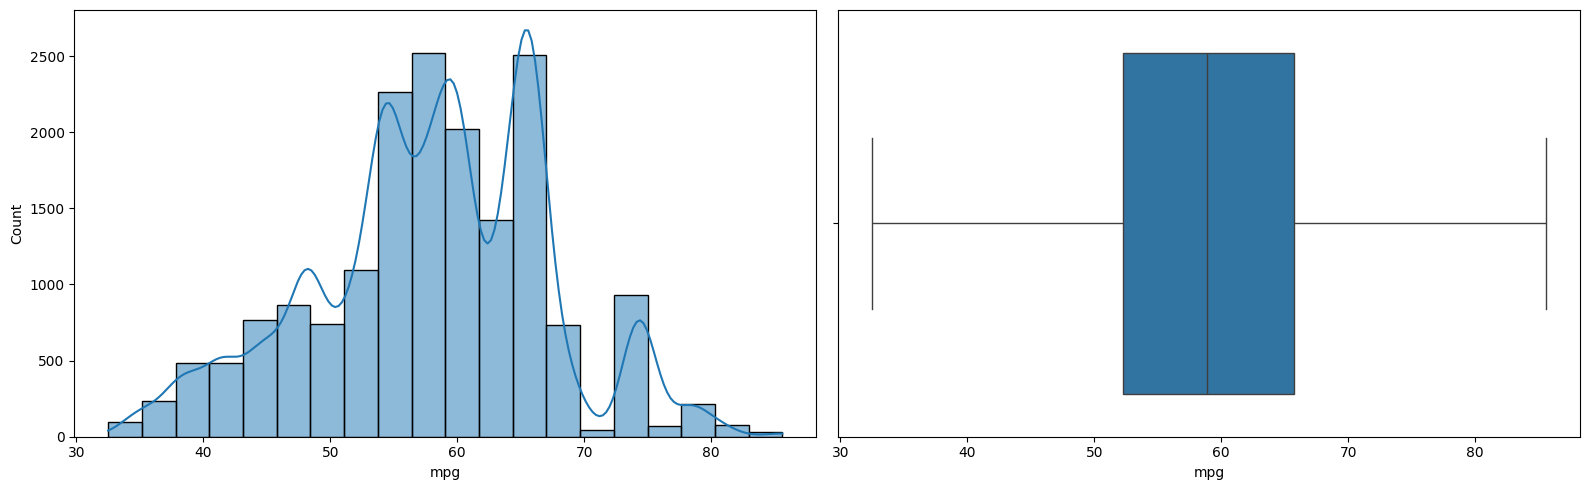

In [34]:
# Make a hist and box plot to see outliers
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.histplot(df_clean["mpg"], bins = 20, kde = True)

plt.subplot(1,2,2)
sns.boxplot(x = df_clean["mpg"])

plt.tight_layout()
plt.show()

Find and Remove outliers from the Engine Size column by different method.

In [35]:
df_clean = df_clean[df_clean["engineSize"] > 0.0]

In [36]:
print(df_clean['engineSize'].value_counts().sort_index())

engineSize
1.0    7702
1.1     550
1.2    1613
1.3      12
1.4     112
1.5    3266
1.6     918
1.7       1
1.8      35
2.0    3256
2.2      13
2.3      66
5.0       1
Name: count, dtype: int64


**Preprocessing**

Create Dummy Variables [One-hot encoding].

In [37]:
df_clean = pd.get_dummies(df_clean, columns = ["model","transmission","fuelType"], drop_first = True)

Create Dependent variable (y) & Independent variable (x),
Distributing data into training and testing.

In [38]:
y = df_clean["price"]
x = df_clean.drop("price", axis = 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 40)

In [39]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [40]:
y_predict = model.predict(x_test)

In [41]:
accuracy = r2_score(y_test, y_predict)
print(f"Final Model Accuracy (R-squared): {accuracy:.2f}")

Final Model Accuracy (R-squared): 0.79


Polynomial Regression...

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

poly = PolynomialFeatures(degree=2, interaction_only=True)
x_train2 = poly.fit_transform(x_train)
x_test2 = poly.fit_transform(x_test)

poly_clf = linear_model.LinearRegression()

poly_clf.fit(x_train2, y_train)

y_pred = poly_clf.predict(x_test2)


#In sample (training) R^2 will always improve with the number of variables!
print(poly_clf.score(x_train2, y_train))

0.9177047490506662


In [43]:
#Out off sample (testing) R^2 is our measure of sucess and does improve
print(poly_clf.score(x_test2, y_test))

0.8737984204169451


In [44]:
# but this improves as the cost of 29 extra variables!
print(x_train.shape)
print(x_train2.shape)

(14036, 33)
(14036, 562)


Pridect Price...

In [45]:
row_number = (int(input("Enter a row number:")))

test_input = x_test.iloc[[row_number]]

original_price = y_test.iloc[row_number]

predicted_price = model.predict(test_input)[0]

difference = abs(original_price - predicted_price)

print(f"TEST DATA PREDICTION CHECK (Row No: {row_number})")
print(f"Original Price    :  {original_price:.2f}")
print(f"Predict Price   :  {predicted_price:.2f}")
print(f"Difference     :  {difference:.2f}")

Enter a row number:5
TEST DATA PREDICTION CHECK (Row No: 5)
Original Price    :  9491.00
Predict Price   :  10392.88
Difference     :  901.88
